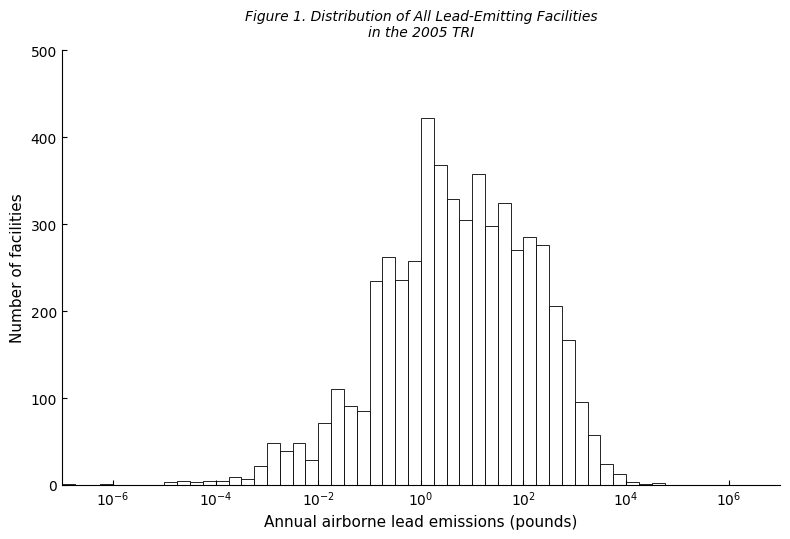

Total facilities: 5375
Valid observations: 5375


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load 2005 TRI data
tri_path = '/Users/murielkai/Desktop/python-venv-demo/race data/TRI_2005_US.csv'
df = pd.read_csv(tri_path, encoding='latin1', low_memory=False)

# Filter for lead emissions only
lead_mask = df['CHEMICAL'].str.upper().str.contains('LEAD', na=False)
df_lead = df[lead_mask].copy()

# Convert all units to pounds
df_lead['air_lbs'] = np.where(
    df_lead['UNIT_OF_MEASURE'].str.strip().str.upper() == 'GRAMS',
    (df_lead['5.1_FUGITIVE_AIR'].fillna(0) + df_lead['5.2_STACK_AIR'].fillna(0)) / 453.592,
    df_lead['5.1_FUGITIVE_AIR'].fillna(0) + df_lead['5.2_STACK_AIR'].fillna(0)
)

# Aggregate to facility level
facility_emissions = df_lead.groupby('TRI_FACILITY_ID')['air_lbs'].sum().reset_index()
facility_emissions = facility_emissions[facility_emissions['air_lbs'] > 0]

log_emissions = np.log10(facility_emissions['air_lbs'])

# ── Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))

# Bin width = 0.25 log units (consistent with original figure)
bins = np.arange(-7, 7.25, 0.25)
ax.hist(log_emissions, bins=bins, color='white', edgecolor='black', linewidth=0.6)

# X-axis: exact tick positions and labels
xtick_pos = [-6, -4, -2, 0, 2, 4, 6]
xtick_labels = [r'$10^{-6}$', r'$10^{-4}$', r'$10^{-2}$',
                r'$10^{0}$', r'$10^{2}$', r'$10^{4}$', r'$10^{6}$']
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_xlim(-7, 7)

# Y-axis
ax.set_ylim(0, 500)
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.tick_params(axis='y', labelsize=10)

# Axis labels
ax.set_xlabel('Annual airborne lead emissions (pounds)', fontsize=11)
ax.set_ylabel('Number of facilities', fontsize=11)

# Title: italic, two-line, centered (matches original)
ax.set_title('Figure 1. Distribution of All Lead-Emitting Facilities\nin the 2005 TRI',
             fontsize=10, style='italic', loc='center', pad=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ticks pointing inward
ax.tick_params(direction='in', which='both')

plt.tight_layout()
plt.savefig('figure1_refined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total facilities: {len(facility_emissions)}")
print(f"Valid observations: {len(log_emissions)}")